In [2]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('main.ipynb'), '..')))

In [3]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.wcs import WCS
import pandas as pd
from scipy import interpolate
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

In [4]:
from utils.utilitas import inputx_outputy
from utils.arsitektur import StarNet
from utils.kma_method import KomodoMlipirAlgorithm
from utils.pre_processing import interpolate_nan, normalize_flux_median, standarize_output,decode_pred,mean_std
import seaborn as sns

In [6]:
#dapatkan data x dan y dimana x adalah flux dan y adalah vektor teff, logg, feh dan vin sin 1
"""
query
SELECT TOP 5000 *
FROM apogeeStar at INNER JOIN 
aspcapStar asr ON at.apogee_id = asr.apogee_id
where at.starflag = 0 
and at.vscatter < 1 and at.rv_logg != -9999 and at.SNR > 200 and asr.aspcapflag =0
and asr.vsini != -9999 and at.telescope = 'apo25m' and m_h != -9999

"""
name_file_1 = 'sdss_spectra_data_bintang_apogee.csv'
name_file_2 = 'file_id.csv'
folder_path = 'spectra_images_apogee'

x, y, wavelength = inputx_outputy(name_file_1, name_file_2, folder_path,untuk='train')
x_val, y_val, wavelength_val = inputx_outputy(name_file_1, name_file_2, folder_path, untuk='test')
#interpolasi nilai nan
for i in range(len(x)):
    x[i] = interpolate_nan(x[i])
    x[i] = normalize_flux_median(x[i],wavelength[i])

for i in range(len(x_val)):
    x_val[i] = interpolate_nan(x_val[i])
    x_val[i] = normalize_flux_median(x_val[i],wavelength_val[i])
    
mean_y,std_y = mean_std(y)   
y = standarize_output(y)

#split data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
#X_train_cnn, X_test_cnn,y_train_cnn,y_test_cnn = train_test_split(X_train,y_train, test_size=0.2,random_state=22)

In [7]:
# komodo n = 5
komodo_5 = [0.63479505, 0.09083289, 0.42500061, 0.25655968, 0.803561,   0.5574774,
 0.84808518, 0.85347074, 0.55757087, 0.44375022, 0.2768684,  0.07376918,
 0.49028438, 0.54182711, 0.63778676, 0.84474267]

#komodo n = 10
komodo_10 = [0.43803341, 0.79255546, 0.25906532, 0.42487103, 0.22479651, 0.66282992,
 0.07376419, 0.61606665, 0.37278885, 0.86455141, 0.33717008, 0.66282992,
 0.77520349, 0.53536994, 0.33717008, 0.16457245]

#komodo = 15
komodo_15 = [0.05668635, 0.48560174, 0.48922369, 0.46012899, 0.46196719, 0.68169073,
 0.24546223, 0.51542717, 0.45423118, 1.,         0.46380473, 0.29096663,
 0.4899689,  0.47045753, 0.47757844, 0.53420781]

In [9]:
starnet_5 = StarNet(X_train,y_train,X_test,y_test)
starnet_10 = StarNet(X_train,y_train,X_test,y_test)
starnet_15 = StarNet(X_train,y_train,X_test,y_test)
#decode
kom_5_parameter = starnet_5.decode(komodo_5)
kom_10_parameter = starnet_10.decode(komodo_10)
kom_15_parameter = starnet_15.decode(komodo_15)
 
print(f'Parameter Komodo n = 5 :{kom_5_parameter}')
print(f'Parameter Komodo n = 10 :{kom_10_parameter}')
print(f'Parameter Komodo n = 15 :{kom_15_parameter}')

Parameter Komodo n = 5 :[40, 16, 'tanh', 'tanh', 'glorot_normal', 'orthogonal', 7, 'elu', 'sigmoid', 'tanh', 'random_uniform', 'zeros', 'variance_scaling', 0.0001, 81, 32]
Parameter Komodo n = 10 :[32, 48, 'tanh', 'tanh', 'random_normal', 'lecun_normal', 2, 'sigmoid', 'tanh', 'elu', 'truncated_normal', 'lecun_normal', 'glorot_normal', 0.0001, 66, 1]
Parameter Komodo n = 15 :[16, 32, 'tanh', 'tanh', 'variance_scaling', 'lecun_uniform', 3, 'sigmoid', 'tanh', 'selu', 'variance_scaling', 'random_uniform', 'variance_scaling', 0.0001, 73, 8]


In [10]:
#train komodo_5
starnet_5.arsitektur_start_net(X_train, y_train, X_test, y_test, kom_5_parameter[0],kom_5_parameter[1],kom_5_parameter[2],kom_5_parameter[3],kom_5_parameter[4],kom_5_parameter[5],kom_5_parameter[6],kom_5_parameter[7],kom_5_parameter[8],kom_5_parameter[9],kom_5_parameter[10],kom_5_parameter[11],kom_5_parameter[12],kom_5_parameter[13],kom_5_parameter[14],kom_5_parameter[15])
hist_5 = starnet_5.history
model_5 = starnet_5.model

Epoch 1/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 270ms/step - loss: 1.1720 - val_loss: 0.9223
Epoch 2/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - loss: 0.9875 - val_loss: 0.8946
Epoch 3/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - loss: 1.0372 - val_loss: 0.8963
Epoch 4/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step - loss: 1.0388 - val_loss: 0.8874
Epoch 5/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 250ms/step - loss: 0.9517 - val_loss: 0.8524
Epoch 6/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step - loss: 0.9492 - val_loss: 0.8188
Epoch 7/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 293ms/step - loss: 0.9152 - val_loss: 0.7653
Epoch 8/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 325ms/step - loss: 0.8515 - val_loss: 0.7077
Epoch 9/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - loss: 0.7919 - val_loss: 0.6653
Epoch 10/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 256ms/step - loss: 0.7073 - val_loss: 0.6430
Epoch 11/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 345ms/step - loss: 0.6716 - val_loss: 0.6275
Epoch 12/81
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 243ms/ste

In [11]:
#train komodo_10
starnet_10.arsitektur_start_net(X_train, y_train, X_test, y_test, kom_10_parameter[0],kom_10_parameter[1],kom_10_parameter[2],kom_10_parameter[3],kom_10_parameter[4],kom_10_parameter[5],kom_10_parameter[6],kom_10_parameter[7],kom_10_parameter[8],kom_10_parameter[9],kom_10_parameter[10],kom_10_parameter[11],kom_10_parameter[12],kom_10_parameter[13],kom_10_parameter[14],kom_10_parameter[15])
hist_10 = starnet_10.history
model_10 = starnet_10.model

Epoch 1/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 140s 214ms/step - loss: 1.2112 - val_loss: 0.6173
Epoch 2/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 143s 215ms/step - loss: 0.6761 - val_loss: 0.5356
Epoch 3/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 130s 206ms/step - loss: 0.5559 - val_loss: 0.4287
Epoch 4/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 125s 198ms/step - loss: 0.4485 - val_loss: 0.3843
Epoch 5/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 126s 200ms/step - loss: 0.3716 - val_loss: 0.2776
Epoch 6/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 125s 198ms/step - loss: 0.2866 - val_loss: 0.3058
Epoch 7/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 126s 200ms/step - loss: 0.2634 - val_loss: 0.2356
Epoch 8/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 125s 198ms/step - loss: 0.2608 - val_loss: 0.2258
Epoch 9/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 141s 197ms/step - loss: 0.2559 - val_loss: 0.2493
Epoch 10/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 125s 198ms/step - loss: 0.2385 - val_loss: 0.2109
Epoch 11/66
632/632 ━━━━━━━━━━━━━━━━━━━━ 124s 197ms/step - loss: 0.2063 - val_loss: 0.2132
Epoch 12

In [12]:
#train komodo_15
starnet_15.arsitektur_start_net(X_train, y_train, X_test, y_test, kom_15_parameter[0],kom_15_parameter[1],kom_15_parameter[2],kom_15_parameter[3],kom_15_parameter[4],kom_15_parameter[5],kom_15_parameter[6],kom_15_parameter[7],kom_15_parameter[8],kom_15_parameter[9],kom_15_parameter[10],kom_15_parameter[11],kom_15_parameter[12],kom_15_parameter[13],kom_15_parameter[14],kom_15_parameter[15])
hist_15 = starnet_15.history
model_15 = starnet_15.model

Epoch 1/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 18s 181ms/step - loss: 1.1102 - val_loss: 0.6750
Epoch 2/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 171ms/step - loss: 0.6818 - val_loss: 0.5836
Epoch 3/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 179ms/step - loss: 0.6314 - val_loss: 0.5220
Epoch 4/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 190ms/step - loss: 0.5248 - val_loss: 0.4505
Epoch 5/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 189ms/step - loss: 0.4626 - val_loss: 0.4128
Epoch 6/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 185ms/step - loss: 0.4636 - val_loss: 0.3267
Epoch 7/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 189ms/step - loss: 0.3018 - val_loss: 0.2983
Epoch 8/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - loss: 0.2978 - val_loss: 0.2448
Epoch 9/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 194ms/step - loss: 0.2371 - val_loss: 0.2181
Epoch 10/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 15s 189ms/step - loss: 0.2183 - val_loss: 0.1951
Epoch 11/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 183ms/step - loss: 0.2025 - val_loss: 0.1981
Epoch 12/73
79/79 ━━━━━━━━━━━━━━━━━━━━ 15

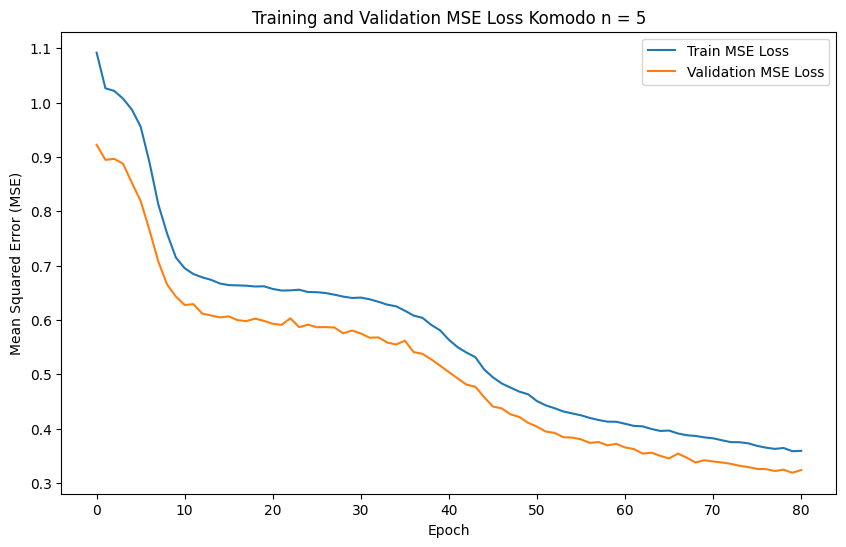

In [13]:
# plot train_valid komodo 5

plt.figure(figsize=(10, 6))
plt.plot(hist_5.history['loss'], label='Train MSE Loss')
plt.plot(hist_5.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 5')
plt.legend()
plt.show()

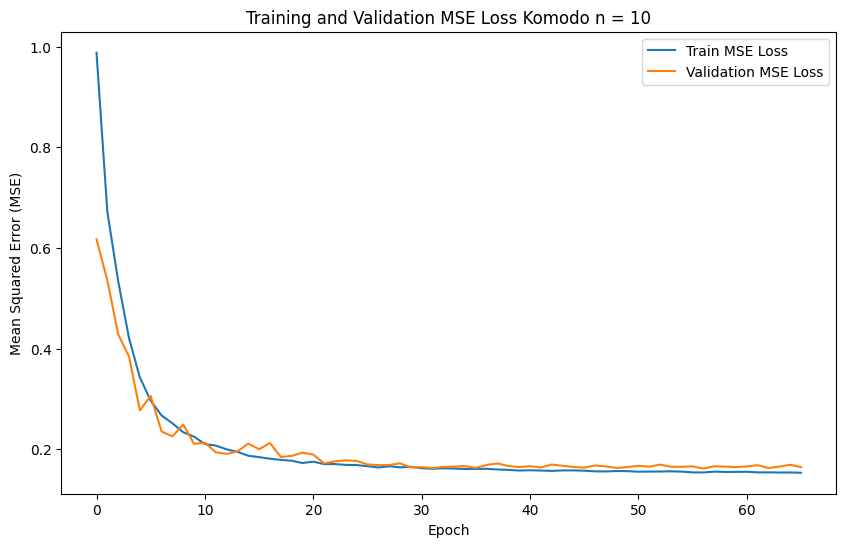

In [14]:
# plot train_valid komodo 10

plt.figure(figsize=(10, 6))
plt.plot(hist_10.history['loss'], label='Train MSE Loss')
plt.plot(hist_10.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 10')
plt.legend()
plt.show()

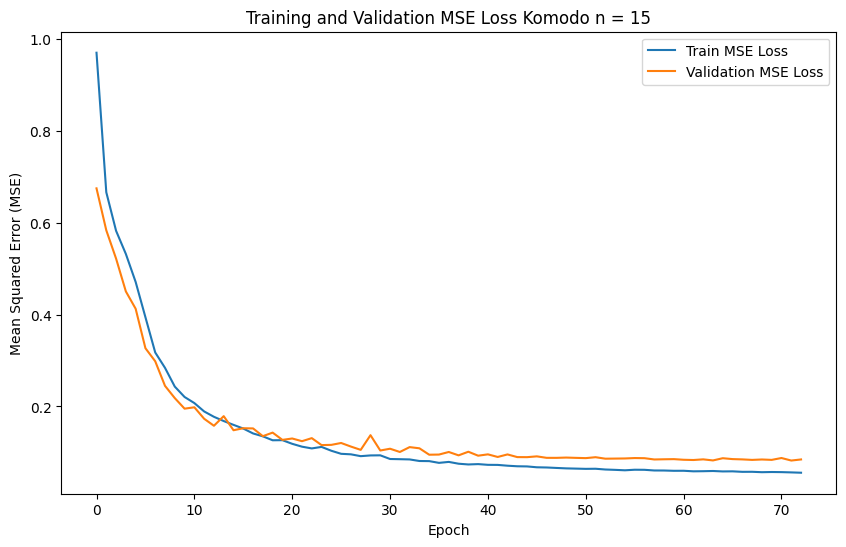

In [15]:
# plot train_valid komodo 15

plt.figure(figsize=(10, 6))
plt.plot(hist_15.history['loss'], label='Train MSE Loss')
plt.plot(hist_15.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 15')
plt.legend()
plt.show()

In [16]:
#hasil prediksi
y_pred_5 = model_5.predict(x_val)
y_pred_10 = model_10.predict(x_val)
y_pred_15 = model_15.predict(x_val)

y_pred_5 = decode_pred(y_pred_5,mean_y,std_y)
y_pred_10 = decode_pred(y_pred_10,mean_y,std_y)
y_pred_15 = decode_pred(y_pred_15,mean_y,std_y)

99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step


In [17]:
#nilai residual
residu_5 = y_pred_5 - y_val
residu_10 = y_pred_10 - y_val
residu_15 = y_pred_15 - y_val

In [33]:
#plot residu SNR > 200

def plot_residu(residu,y_true,parameter):
    if parameter == 'teff':
        res = [teff[0] for teff in residu]
        y = [teff_true[0] for teff_true in y_true]
        kata = '$T_{eff}$'
        kata2 = '$\Delta T_{eff}$'
    elif parameter == 'log_g':
        res = [logg[1] for logg in residu]
        y = [logg_true[1] for logg_true in y_true]
        kata = '$log g$'
        kata2 = '$\Delta log g$'
    elif parameter == 'vsini':
        res = [vsini[2] for vsini in residu]
        y = [vsini_true[2] for vsini_true in y_true]
        kata = '$v sin i$'
        kata2 = '$\Delta v sin i$' 
    else:
        res = [metal[3] for metal in residu]
        y = [metal_true[3] for metal_true in y_true]
        kata = '$M/H$'
        kata2 = '$\Delta M/H$'
    
    res = np.array(res)
    y = np.array(y)
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [3, 1]})


    ax[0].scatter(y, res, color='blue', s=10, alpha=0.7)
    ax[0].axhline(0, color='gray', linestyle='--', linewidth=1)
    ax[0].set_xlabel(f'ASPCAP DR17 {kata}')
    ax[0].set_ylabel(f'{kata2} (StarNet - DR17)')

    # Hitung rata-rata dan standar deviasi residual
    mean_residual = np.mean(res)
    std_residual = np.std(res)
    
    # Hitung posisi tengah pada sumbu x dan y
    x_center = (y.min() + y.max()) / 2  # Posisi tengah sumbu x
    y_center = 0  # Agar teks berada dekat dengan garis nol pada sumbu y
    
    # Tambahkan teks di tengah
    ax[0].text(x_center, y_center, f"$\\bar{{m}}$={mean_residual:.2f}, $s$={std_residual:.2f}",
               fontsize=10, ha='center', va='center', bbox=dict(facecolor='white', alpha=0.5))

    # Histogram distribusi residual di kanan
    sns.histplot(res, bins=30, kde=True, ax=ax[1], color='blue', orientation='horizontal')
    ax[1].set_ylabel('')
    ax[1].set_xlabel('Density')
    ax[1].axhline(0, color='gray', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
C:\Users\itdev.support22\AppData\Local\Temp\ipykernel_5736\3810704085.py:8: SyntaxWarning: invalid escape sequence '\D'
  kata2 = '$\Delta T_{eff}$'
C:\Users\itdev.support22\AppData\Local\Temp\ipykernel_5736\3810704085.py:13: SyntaxWarning: invalid escape sequence '\D'
  kata2 = '$\Delta log g$'
C:\Users\itdev.support22\AppData\Local\Temp\ipykernel_5736\3810704085.py:18: SyntaxWarning: invalid escape sequence '\D'
  kata2 = '$\Delta v sin i$'
C:\Users\itdev.support22\AppData\Local\Temp\ipykernel_5736\3810704085.py:23: SyntaxWarning: invalid escape sequence '\D'
  kata2 = '$\Delta M/H$'


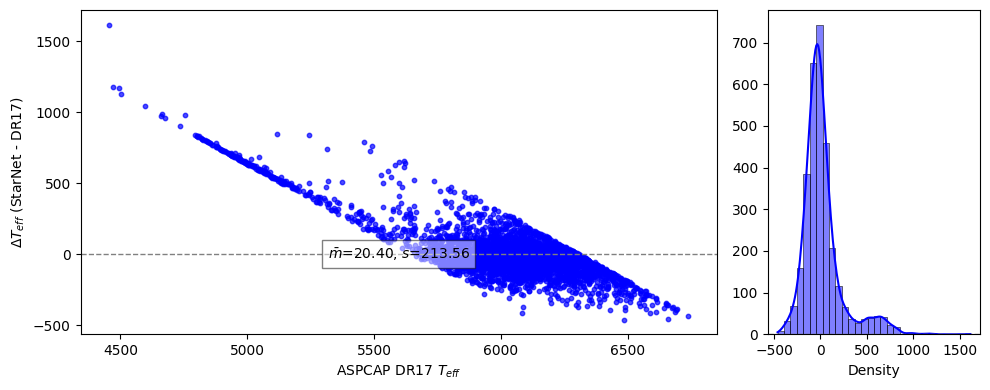

In [34]:
#plot residu teff 5

plot_residu(residu_5,y_val,'teff')


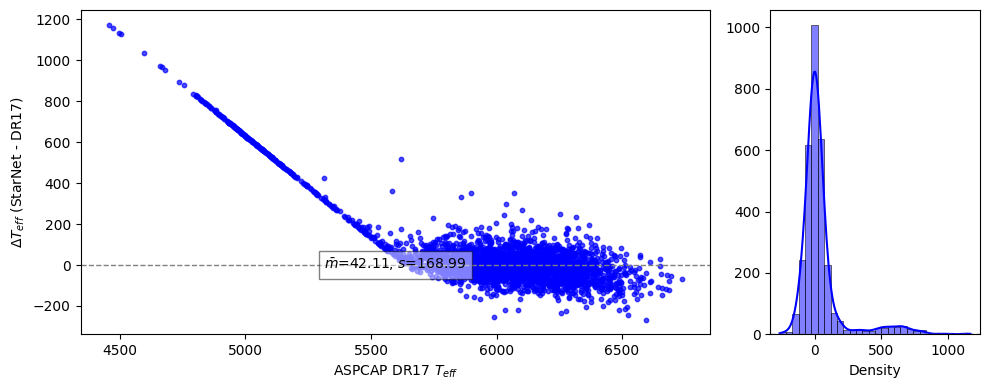

In [35]:
#plot residu teff 10

plot_residu(residu_10,y_val,'teff')

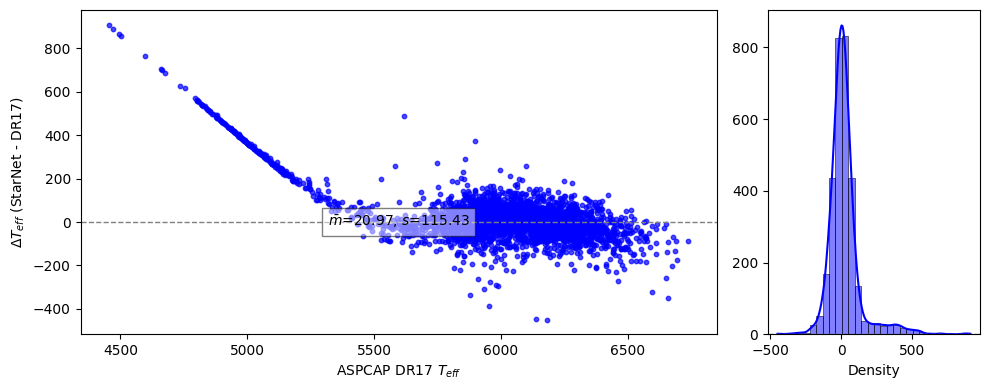

In [36]:
#plot residu teff 15

plot_residu(residu_15,y_val,'teff')

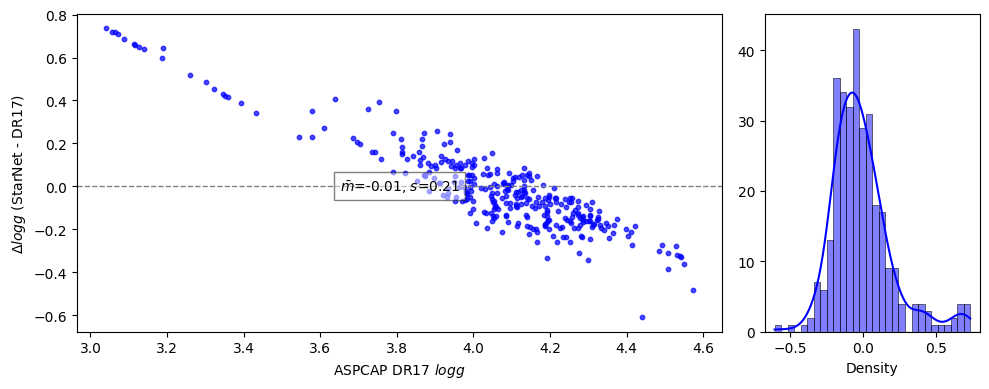

In [37]:
#plot residu logg 5
sub = 10
plot_residu(residu_5[::sub],y_val[::sub],'log_g')

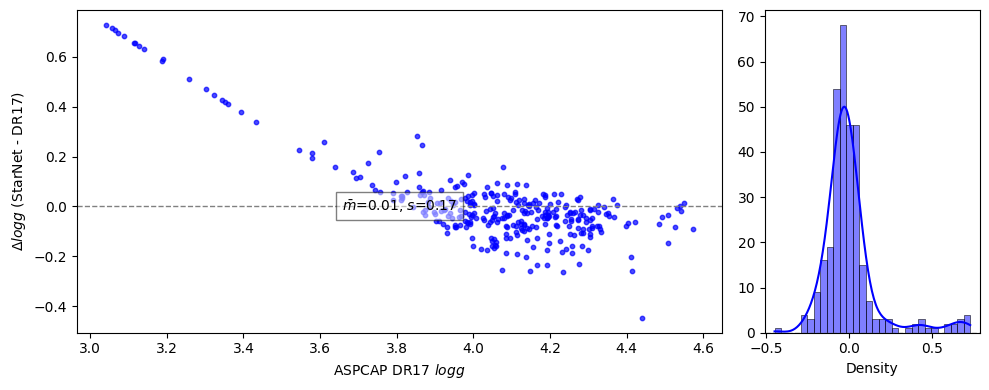

In [38]:
#plot residu logg 10
plot_residu(residu_10[::sub],y_val[::sub],'log_g')

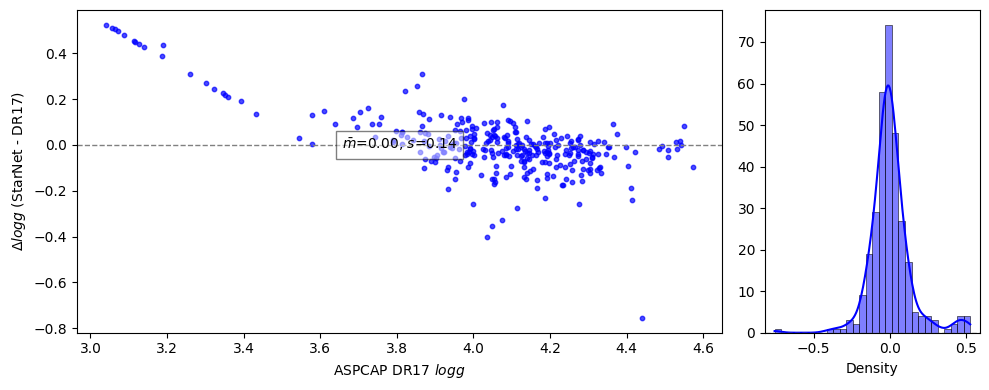

In [39]:
#plot residu logg 15
plot_residu(residu_15[::sub],y_val[::sub],'log_g')

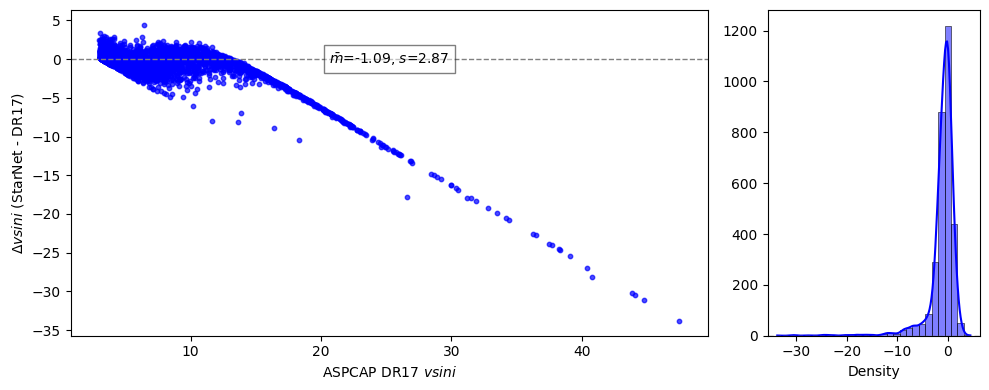

In [40]:
#plot residu vsini 5
plot_residu(residu_5,y_val,'vsini')

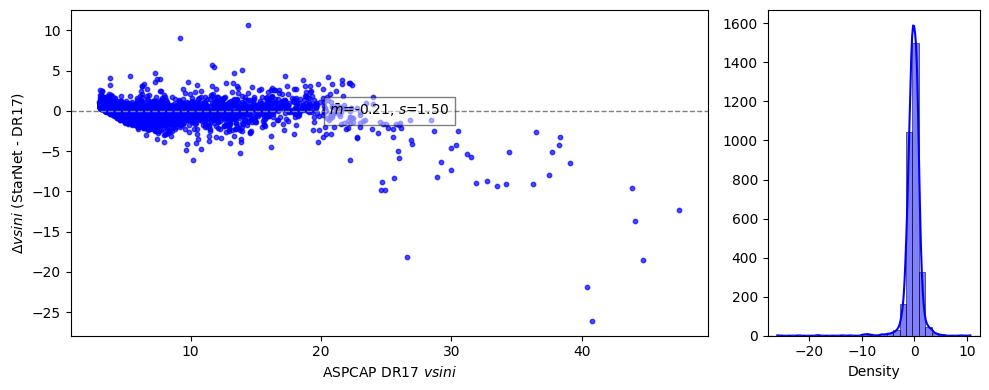

In [41]:
#plot residu vsini 10
plot_residu(residu_10,y_val,'vsini')

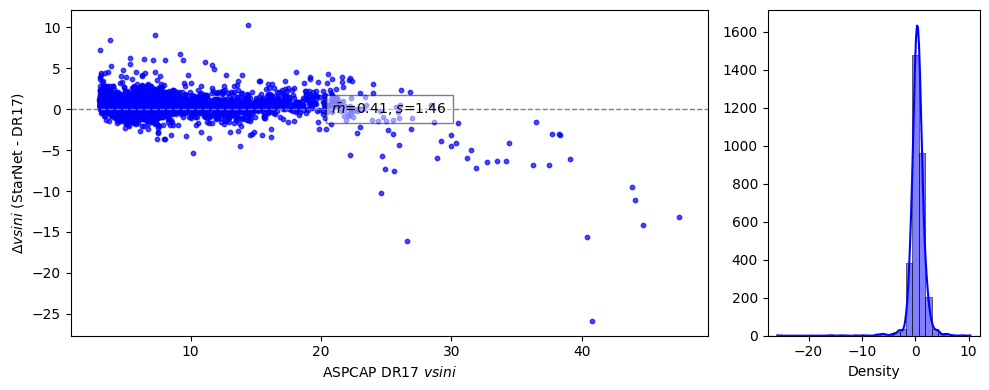

In [42]:
#plot residu vsini 15
plot_residu(residu_15,y_val,'vsini')

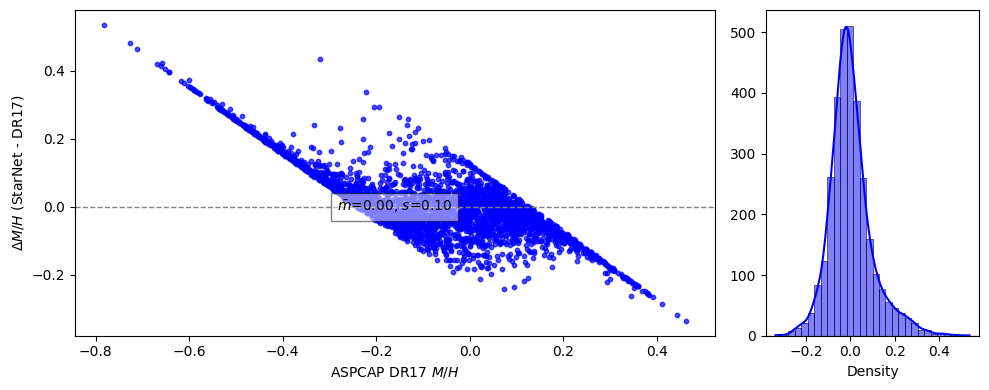

In [43]:
#plot residu  metalisitas 5
plot_residu(residu_5,y_val,'metal')

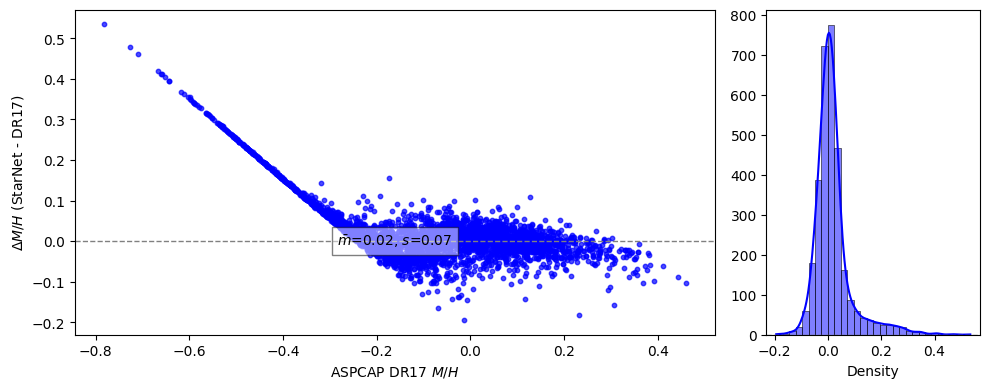

In [44]:
#plot residu  metalisitas 10
plot_residu(residu_10,y_val,'metal')

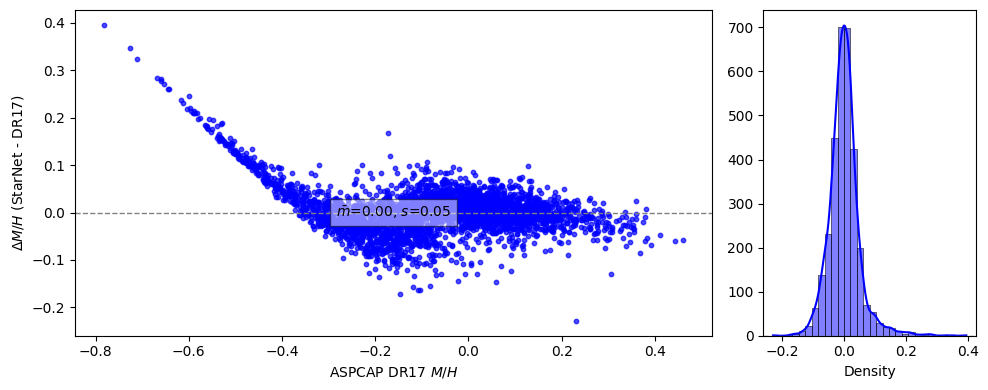

In [45]:
#plot residu  metalisitas 15
plot_residu(residu_15,y_val,'metal')

SNR < 200

In [46]:
#dapatkan data x dan y dimana x adalah flux dan y adalah vektor teff, logg, feh dan vin sin 1
"""
query
SELECT TOP 5000 *
FROM apogeeStar at INNER JOIN 
aspcapStar asr ON at.apogee_id = asr.apogee_id
where at.starflag = 0 
and at.vscatter < 1 and at.rv_logg != -9999 and at.SNR <= 200 and asr.aspcapflag =0
and asr.vsini != -9999 and at.telescope = 'apo25m' and m_h != -9999

"""
name_file_1 = 'sdss_spectra_data_bintang_apogee_low_SNR.csv'
name_file_2 = 'file_id_low_snr.csv'
folder_path = 'spectra_images_apogee_low_SNR'

x_low, y_low, wavelength_low = inputx_outputy(name_file_1, name_file_2, folder_path,untuk='train')
x_val_low, y_val_low, wavelength_val_low = inputx_outputy(name_file_1, name_file_2, folder_path, untuk='test')
#interpolasi nilai nan
for i in range(len(x_low)):
    x_low[i] = interpolate_nan(x_low[i])
    x_low[i] = normalize_flux_median(x_low[i],wavelength_low[i])

for i in range(len(x_val_low)):
    x_val_low[i] = interpolate_nan(x_val_low[i])
    x_val_low[i] = normalize_flux_median(x_val_low[i],wavelength_val_low[i])
    
mean_y_low,std_y_low = mean_std(y_low)   
y_low = standarize_output(y_low)

#split data menjadi data latih dan data uji
X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(x_low, y_low, test_size=0.2, random_state=42)
#X_train_cnn, X_test_cnn,y_train_cnn,y_test_cnn = train_test_split(X_train,y_train, test_size=0.2,random_state=22)

In [47]:
starnet_5_low = StarNet(X_train_low,y_train_low,X_test_low,y_test_low)
starnet_10_low = StarNet(X_train_low,y_train_low,X_test_low,y_test_low)
starnet_15_low = StarNet(X_train_low,y_train_low,X_test_low,y_test_low)

In [48]:
#train komodo_5
starnet_5_low.arsitektur_start_net(X_train_low, y_train_low, X_test_low, y_test_low, kom_5_parameter[0],kom_5_parameter[1],kom_5_parameter[2],kom_5_parameter[3],kom_5_parameter[4],kom_5_parameter[5],kom_5_parameter[6],kom_5_parameter[7],kom_5_parameter[8],kom_5_parameter[9],kom_5_parameter[10],kom_5_parameter[11],kom_5_parameter[12],kom_5_parameter[13],kom_5_parameter[14],kom_5_parameter[15])
hist_5_low = starnet_5_low.history
model_5_low = starnet_5_low.model

Epoch 1/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 252ms/step - loss: 1.1793 - val_loss: 0.8243
Epoch 2/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 231ms/step - loss: 1.0004 - val_loss: 0.8098
Epoch 3/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 186ms/step - loss: 1.0751 - val_loss: 0.8017
Epoch 4/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 186ms/step - loss: 1.0586 - val_loss: 0.8265
Epoch 5/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 188ms/step - loss: 1.0303 - val_loss: 0.8042
Epoch 6/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - loss: 1.0814 - val_loss: 0.8018
Epoch 7/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - loss: 1.0031 - val_loss: 0.7973
Epoch 8/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - loss: 1.0606 - val_loss: 0.7952
Epoch 9/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - loss: 1.0212 - val_loss: 0.7960
Epoch 10/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - loss: 1.0995 - val_loss: 0.7686
Epoch 11/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step - loss: 1.0229 - val_loss: 0.7531
Epoch 12/81
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step

In [49]:
#train komodo_10
starnet_10_low.arsitektur_start_net(X_train_low, y_train_low, X_test_low, y_test_low, kom_10_parameter[0],kom_10_parameter[1],kom_10_parameter[2],kom_10_parameter[3],kom_10_parameter[4],kom_10_parameter[5],kom_10_parameter[6],kom_10_parameter[7],kom_10_parameter[8],kom_10_parameter[9],kom_10_parameter[10],kom_10_parameter[11],kom_10_parameter[12],kom_10_parameter[13],kom_10_parameter[14],kom_10_parameter[15])
hist_10_low = starnet_10_low.history
model_10_low = starnet_10_low.model

Epoch 1/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 114s 194ms/step - loss: 1.0628 - val_loss: 0.5397
Epoch 2/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 106s 186ms/step - loss: 0.6128 - val_loss: 0.3815
Epoch 3/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 141s 184ms/step - loss: 0.5718 - val_loss: 0.2844
Epoch 4/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 107s 187ms/step - loss: 0.3207 - val_loss: 0.3247
Epoch 5/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 107s 187ms/step - loss: 0.3738 - val_loss: 0.2574
Epoch 6/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 106s 186ms/step - loss: 0.3444 - val_loss: 0.2688
Epoch 7/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 107s 187ms/step - loss: 0.2900 - val_loss: 0.2357
Epoch 8/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 141s 185ms/step - loss: 0.2468 - val_loss: 0.2366
Epoch 9/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 106s 185ms/step - loss: 0.2493 - val_loss: 0.2283
Epoch 10/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 109s 191ms/step - loss: 0.2317 - val_loss: 0.2714
Epoch 11/66
572/572 ━━━━━━━━━━━━━━━━━━━━ 137s 182ms/step - loss: 0.2190 - val_loss: 0.2256
Epoch 12

In [50]:
#train komodo_15
starnet_15_low.arsitektur_start_net(X_train_low, y_train_low, X_test_low, y_test_low, kom_15_parameter[0],kom_15_parameter[1],kom_15_parameter[2],kom_15_parameter[3],kom_15_parameter[4],kom_15_parameter[5],kom_15_parameter[6],kom_15_parameter[7],kom_15_parameter[8],kom_15_parameter[9],kom_15_parameter[10],kom_15_parameter[11],kom_15_parameter[12],kom_15_parameter[13],kom_15_parameter[14],kom_15_parameter[15])
hist_15_low = starnet_15_low.history
model_15_low = starnet_15_low.model

Epoch 1/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 170ms/step - loss: 1.2787 - val_loss: 0.8157
Epoch 2/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 164ms/step - loss: 1.0468 - val_loss: 0.8226
Epoch 3/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 156ms/step - loss: 1.0392 - val_loss: 0.8104
Epoch 4/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - loss: 1.1391 - val_loss: 0.8117
Epoch 5/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 166ms/step - loss: 1.0811 - val_loss: 0.8065
Epoch 6/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 167ms/step - loss: 1.0525 - val_loss: 0.8024
Epoch 7/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 165ms/step - loss: 1.1101 - val_loss: 0.8063
Epoch 8/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 154ms/step - loss: 0.9696 - val_loss: 0.8455
Epoch 9/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 154ms/step - loss: 1.1192 - val_loss: 0.8070
Epoch 10/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 155ms/step - loss: 0.9759 - val_loss: 0.8161
Epoch 11/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - loss: 0.9974 - val_loss: 0.8113
Epoch 12/73
72/72 ━━━━━━━━━━━━━━━━━━━━ 12

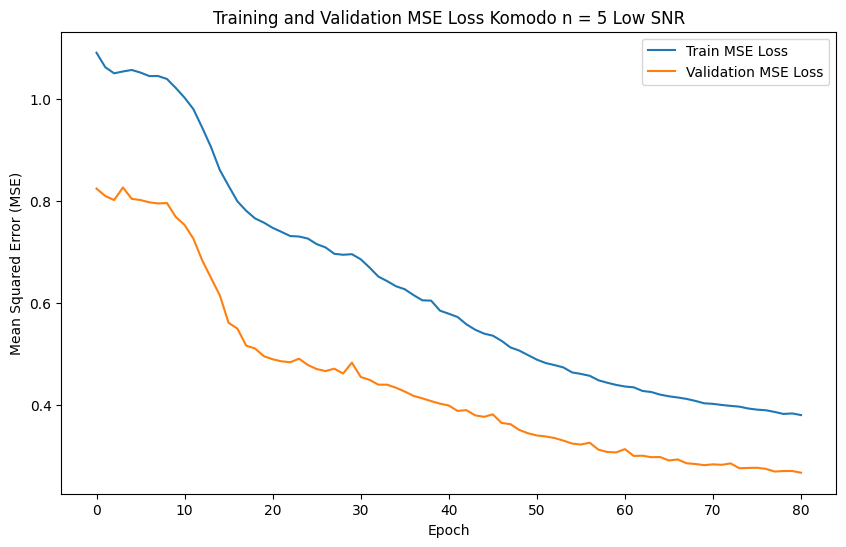

In [51]:
# plot train_valid komodo 5

plt.figure(figsize=(10, 6))
plt.plot(hist_5_low.history['loss'], label='Train MSE Loss')
plt.plot(hist_5_low.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 5 Low SNR')
plt.legend()
plt.show()

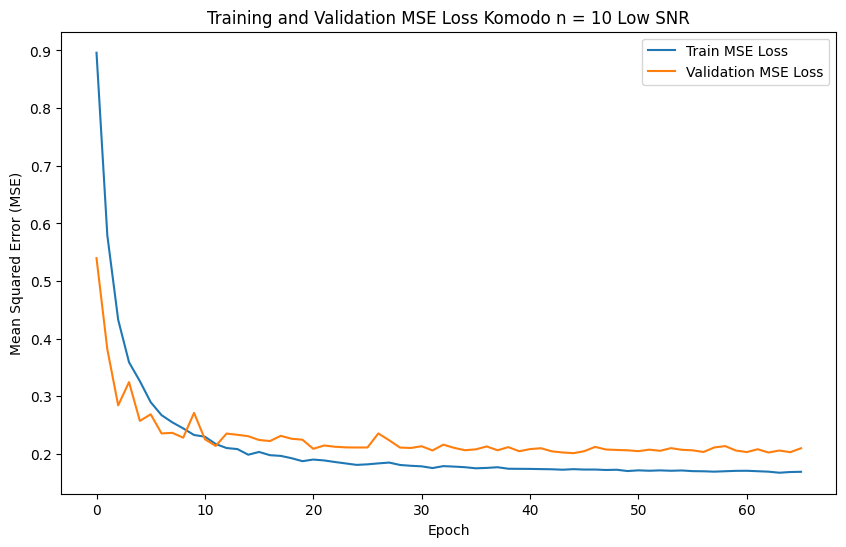

In [52]:
# plot train_valid komodo 10

plt.figure(figsize=(10, 6))
plt.plot(hist_10_low.history['loss'], label='Train MSE Loss')
plt.plot(hist_10_low.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 10 Low SNR')
plt.legend()
plt.show()

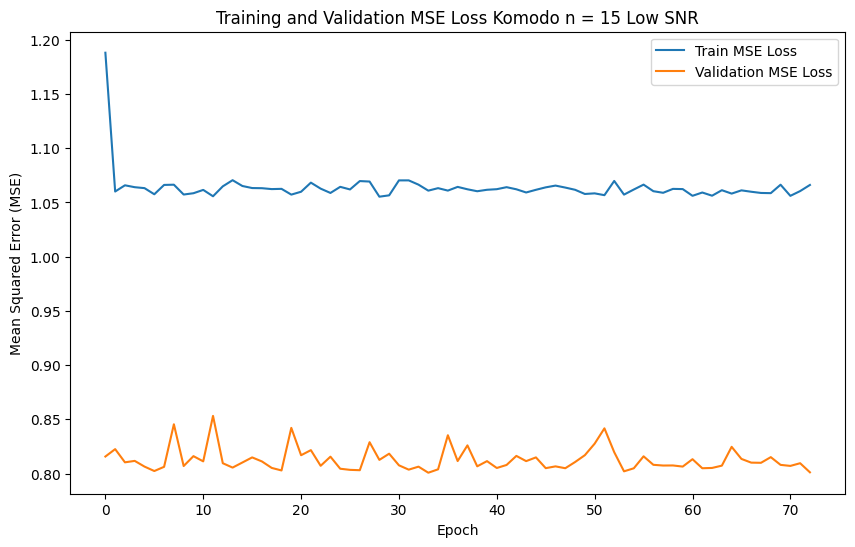

In [53]:
# plot train_valid komodo 15

plt.figure(figsize=(10, 6))
plt.plot(hist_15_low.history['loss'], label='Train MSE Loss')
plt.plot(hist_15_low.history['val_loss'], label='Validation MSE Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Training and Validation MSE Loss Komodo n = 15 Low SNR')
plt.legend()
plt.show()

In [54]:
y_pred_5_low = model_5_low.predict(x_val_low)
y_pred_10_low = model_10_low.predict(x_val_low)
y_pred_15_low = model_15_low.predict(x_val_low)

y_pred_5_low = decode_pred(y_pred_5_low,mean_y_low,std_y_low)
y_pred_10_low = decode_pred(y_pred_10_low,mean_y_low,std_y_low)
y_pred_15_low = decode_pred(y_pred_15_low,mean_y_low,std_y_low)

90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step


In [55]:
y_pred_5 = model_5.predict(x_val)
y_pred_10 = model_10.predict(x_val)
y_pred_15 = model_15.predict(x_val)

y_pred_5 = decode_pred(y_pred_5,mean_y,std_y)
y_pred_10 = decode_pred(y_pred_10,mean_y,std_y)
y_pred_15 = decode_pred(y_pred_15,mean_y,std_y)

99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step


In [56]:
#nilai residual
residu_5_low = y_pred_5_low - y_val_low
residu_10_low = y_pred_10_low - y_val_low
residu_15_low = y_pred_15_low - y_val_low

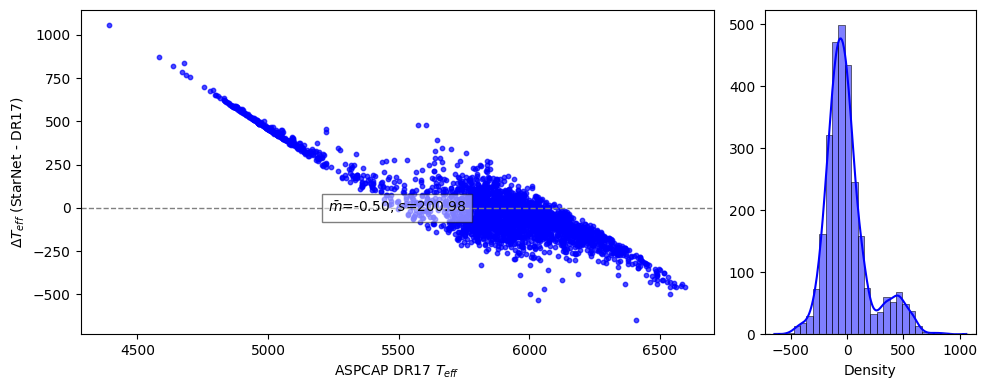

In [57]:
#plot residu teff 5

plot_residu(residu_5_low,y_val_low,'teff')

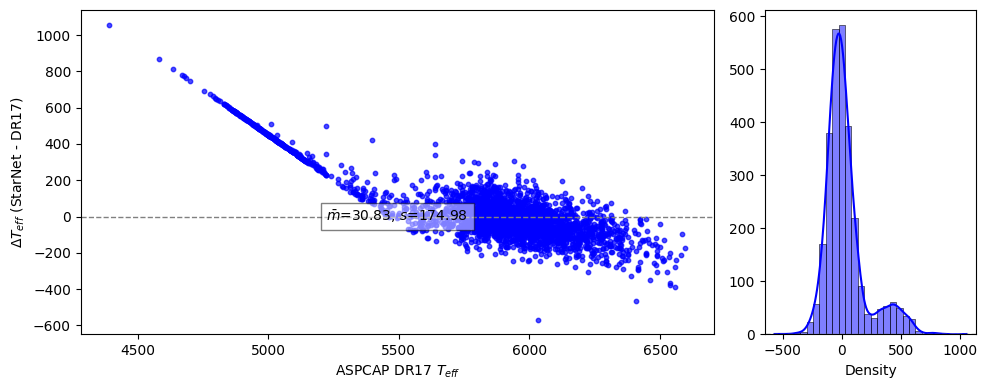

In [58]:
#plot residu teff 10

plot_residu(residu_10_low,y_val_low,'teff')

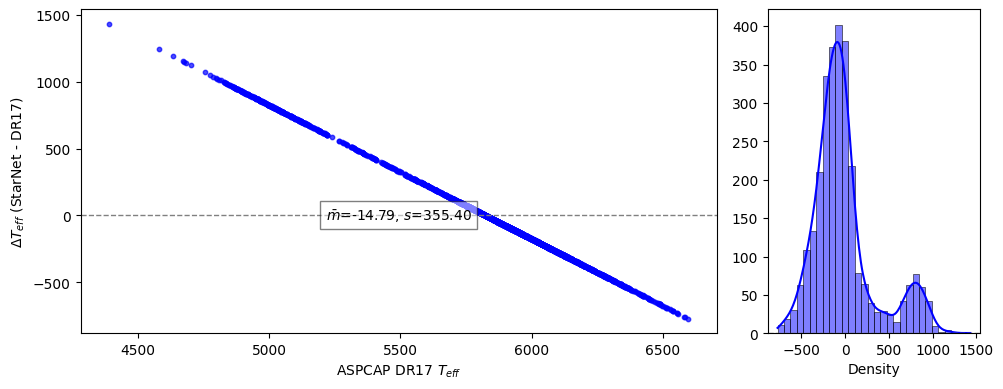

In [59]:
#plot residu teff 15

plot_residu(residu_15_low,y_val_low,'teff')

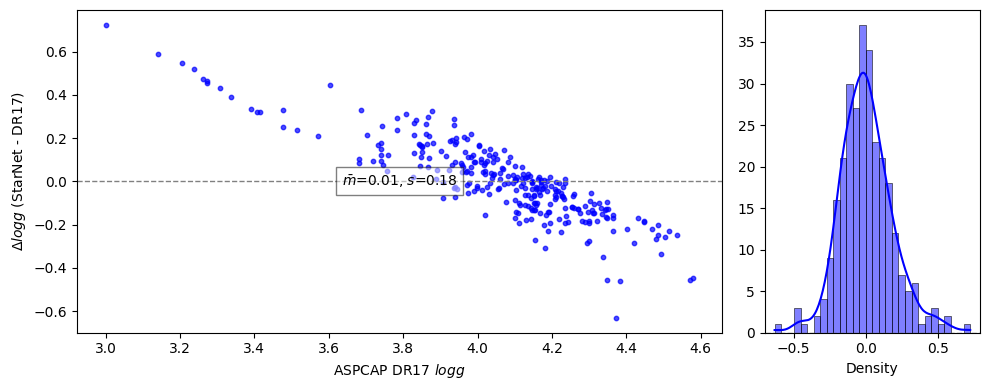

In [60]:
#plot residu logg 5
sub = 10
plot_residu(residu_5_low[::sub],y_val_low[::sub],'log_g')

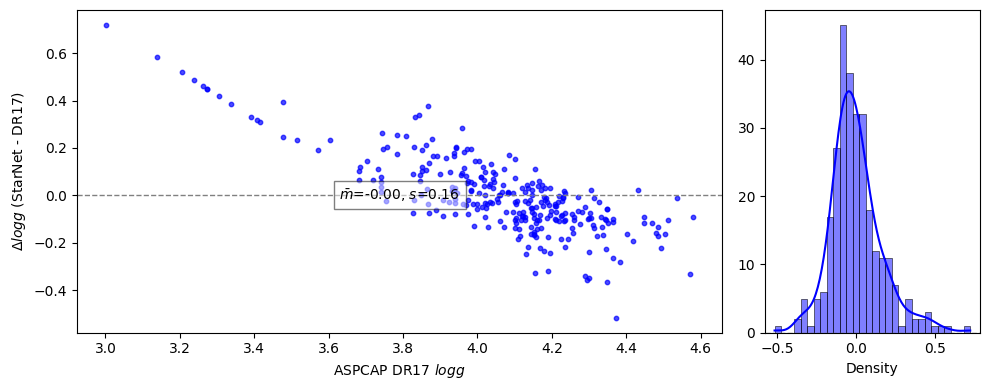

In [61]:
#plot residu logg 10
plot_residu(residu_10_low[::sub],y_val_low[::sub],'log_g')

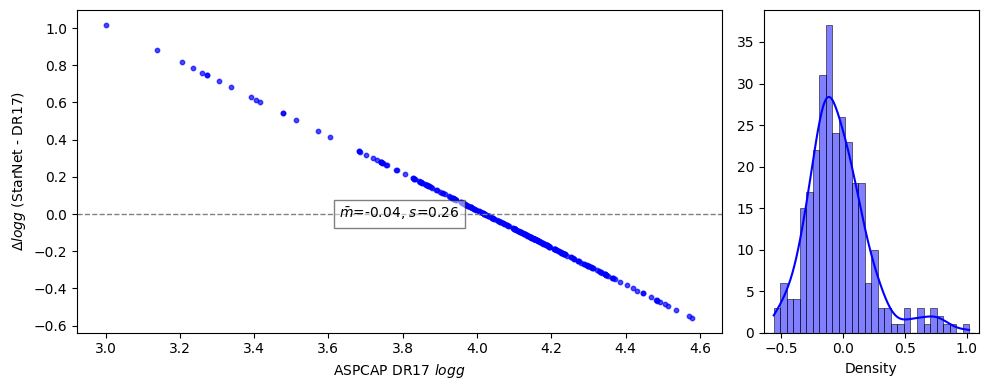

In [62]:
#plot residu logg 15
plot_residu(residu_15_low[::sub],y_val_low[::sub],'log_g')

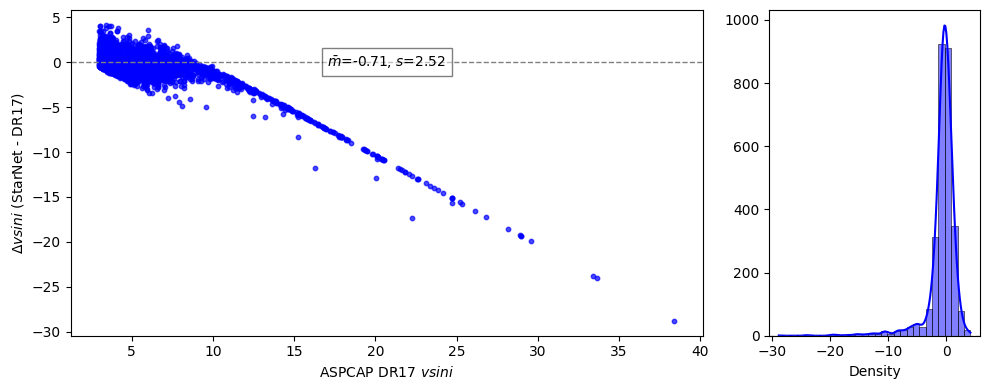

In [63]:
#plot residu vsini 5
plot_residu(residu_5_low,y_val_low,'vsini')

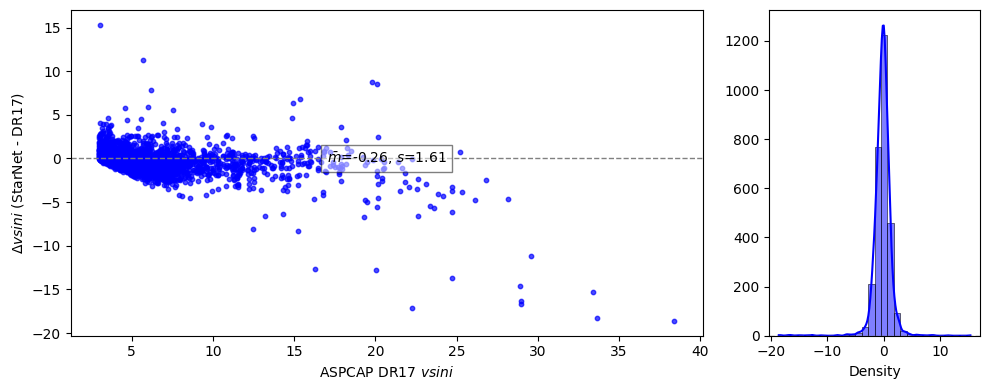

In [64]:
#plot residu vsini 10
plot_residu(residu_10_low,y_val_low,'vsini')

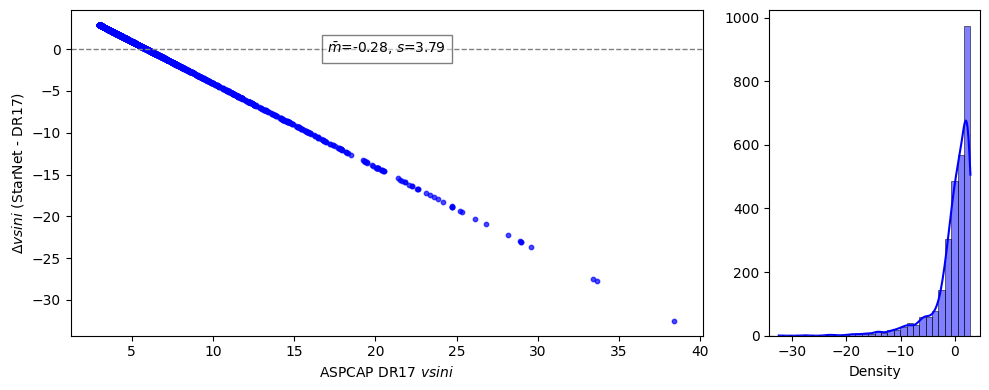

In [65]:
#plot residu vsini 15
plot_residu(residu_15_low,y_val_low,'vsini')

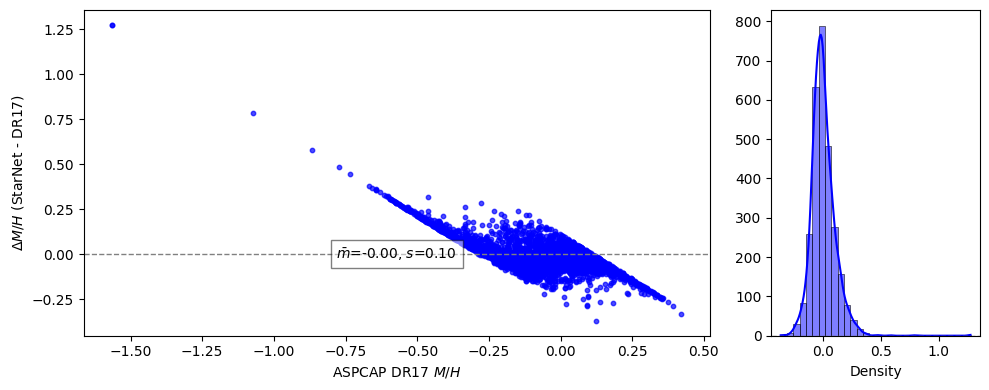

In [66]:
#plot residu  metalisitas 5
plot_residu(residu_5_low,y_val_low,'metal')

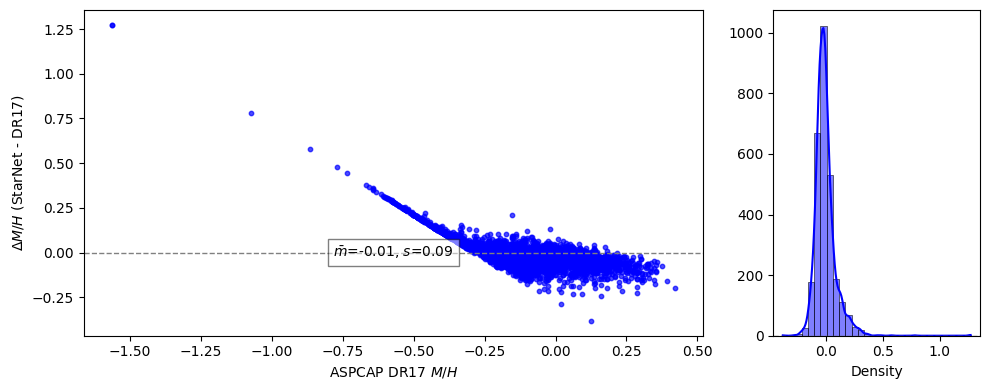

In [67]:
#plot residu  metalisitas 10
plot_residu(residu_10_low,y_val_low,'metal')

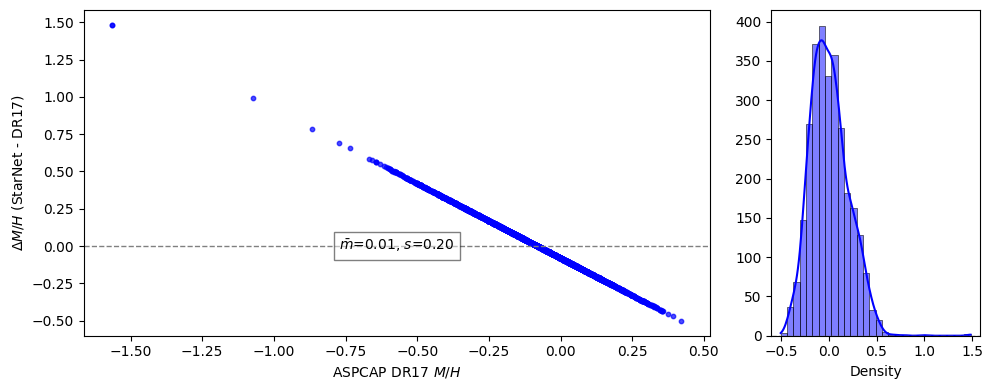

In [68]:
#plot residu  metalisitas 15
plot_residu(residu_15_low,y_val_low,'metal')